In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/Users/hrchapmandutton/Documents/Projects/CDW/fires_2001_2019_single_burn_clip_permaprob.csv')
df.columns

Index(['Join_Count', 'TARGET_FID', 'NAME', 'RECORDNUMB', 'ACRES', 'PERIMETERD',
       'SOURCE', 'SOURCEMETH', 'SOURCECLAS', 'AGENCYACRE', 'COMMENTS',
       'FIREID', 'FIREYEAR', 'UPDATETIME', 'FPOUTDATE', 'IRWINID',
       'PRESCRIBED', 'FIRESEASON', 'UniqueID', 'area_sqkm', 'perunbrn',
       'SRC_AGENCY', 'NAT_PARK', 'MONTH', 'DAY', 'REP_DATE', 'DATE_TYPE',
       'DECADE', 'SIZE_HA', 'CALC_HA', 'SOURCE_KEY', 'MORE_INFO', 'CFS_REF_ID',
       'border_fir', 'count', 'per_single', 'Shape_Leng', 'Shape_Area',
       'area_clipp', 'NA_L1NAME', 'NA_L1KEY', 'Unique_ID', 'FrAreaKm', 'GHG',
       'Permafrost', 'Albedo', 'Recovery', 'NetRF', 'Country', 'PermProb',
       'MaxData', 'PermaData'],
      dtype='object')

In [3]:
df_filter = df[df['MaxData'] == 'yes']
df_filter=df_filter[df_filter['NA_L1NAME']!='NORTH AMERICAN DESERTS']

In [4]:
print(df_filter['PRESCRIBED'].unique())

['N' 'Y' ' ' 'yes']


In [5]:
df_filter['PRESCRIBED'] = df_filter['PRESCRIBED'].replace({'yes': 'Y', ' ': 'N'})
print(df_filter['PRESCRIBED'].unique())

['N' 'Y']


In [21]:
print(df_filter['MONTH'].unique())

[ 0  6  7  8  4  5  9 10 11  1  3  2 12]


In [6]:
df_filter['MONTH'] = df_filter['MONTH'].replace(0, np.nan)
print(df_filter['MONTH'].unique())

[nan  6.  7.  8.  4.  5.  9. 10. 11.  1.  3.  2. 12.]


In [7]:
cats = ['NA_L1NAME', 'FIREYEAR', 'MONTH', 'PRESCRIBED', 'NetRF']
df_RF = df_filter[cats]
df_RF.head()

,NA_L1NAME,FIREYEAR,MONTH,PRESCRIBED,NetRF
0,NORTHWESTERN FORESTED MOUNTAINS,2019,NaN,N,-0.695913
1,TAIGA,2019,NaN,N,5.092502
2,TAIGA,2019,NaN,N,9.731596
3,MARINE WEST COAST FOREST,2019,NaN,N,0.379457
4,NORTHWESTERN FORESTED MOUNTAINS,2019,NaN,N,1.606471


In [ ]:
#netRF by ecoregion (and combined) for prescribed vs. non-prescribed fires

/var/folders/sq/yw612wzn25s9n4pclwvt88m40000gq/T/ipykernel_28829/1560468096.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


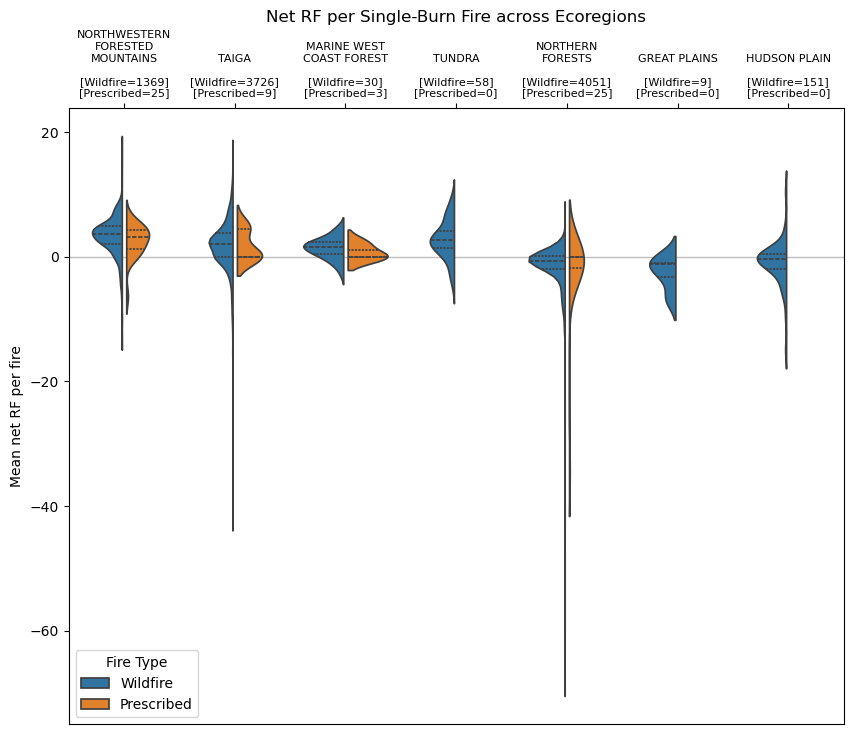

In [67]:
plt.figure(figsize=(10,8))
ax = sns.violinplot(data=df_RF, x='NA_L1NAME', y='NetRF', hue='PRESCRIBED', split=True, gap=0.1, inner="quartile")

order = [t.get_text() for t in ax.get_xticklabels()]
by_type = (
    df_RF.groupby(["NA_L1NAME", "PRESCRIBED"])
.size()
    .unstack(fill_value=0)
)

import textwrap

labels = []
for name in order:
    y_count = by_type.loc[name, "Y"] if "Y" in by_type.columns and name in by_type.index else 0
    n_count = by_type.loc[name, "N"] if "N" in by_type.columns and name in by_type.index else 0
    wrapped_name = textwrap.fill(name, width=12)
    labels.append(f"{wrapped_name}\n\n[Wildfire={n_count}]\n[Prescribed={y_count}]")

ax.set_xticklabels(labels)

handles, current_labels = ax.get_legend_handles_labels()
label_map = {"N": "Wildfire", "Y": "Prescribed"}
new_labels = [label_map.get(label, label) for label in current_labels]
ax.legend(handles=handles, labels=new_labels, title="Fire Type")

ax.axhline(0, color='gray', linewidth=1, alpha=0.5, zorder=0)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.tick_params(axis='x', labelsize=8)

plt.xlabel('')
plt.ylabel('Mean net RF per fire')
plt.title('Net RF per Single-Burn Fire across Ecoregions')
plt.show()

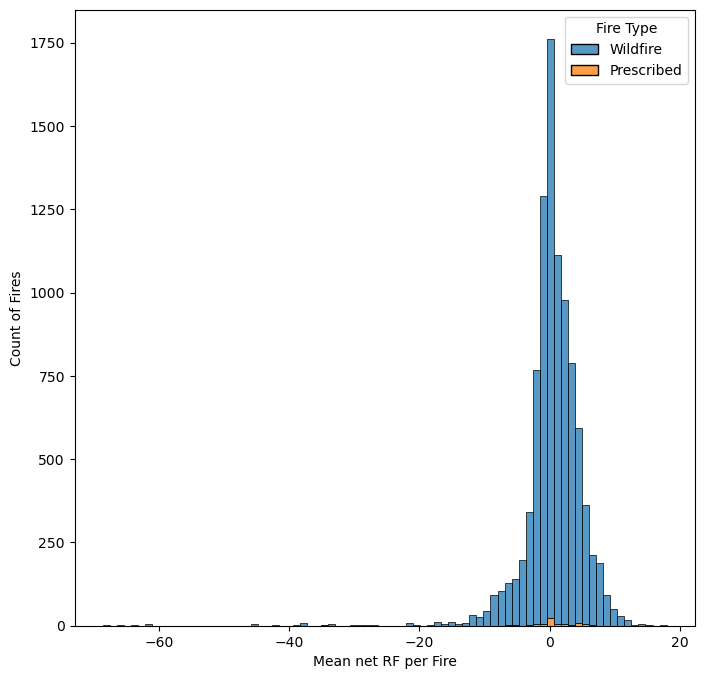

In [79]:
plt.figure(figsize=(8,8))
ax = sns.histplot(data=df_RF, x='NetRF', hue='PRESCRIBED', bins=80, multiple="stack")

label_map = {"N": "Wildfire", "Y": "Prescribed"}
ax.legend_.set_title("Fire Type")
for text in ax.legend_.texts:
    text.set_text(label_map.get(text.get_text(), text.get_text()))

plt.xlabel('Mean net RF per Fire')
plt.ylabel('Count of Fires')

plt.show()

In [ ]:
#contributions of prescribed vs. non-prescribed fires to total net RF, and by ecoregion

In [ ]:
#netRF by month, and by month by ecoregion

<Figure size 800x800 with 0 Axes>

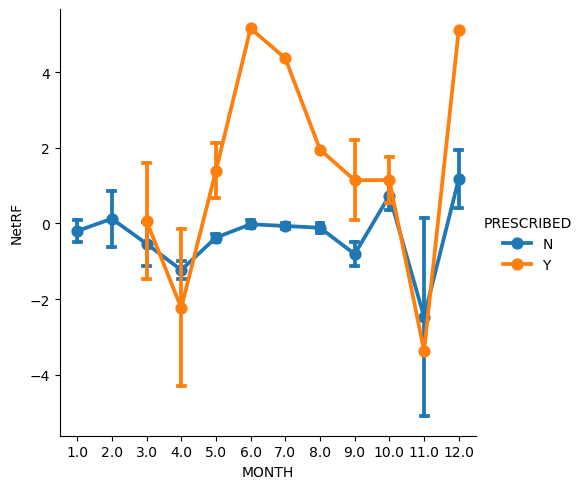

In [21]:
plt.figure(figsize=(8,8))
ax = sns.catplot(data=df_RF, x='MONTH', y='NetRF', hue='PRESCRIBED', capsize=.2, kind='point', errorbar='se')
#ax.axhline(0, color='gray', linewidth=1, alpha=0.5, zorder=0)
plt.show()

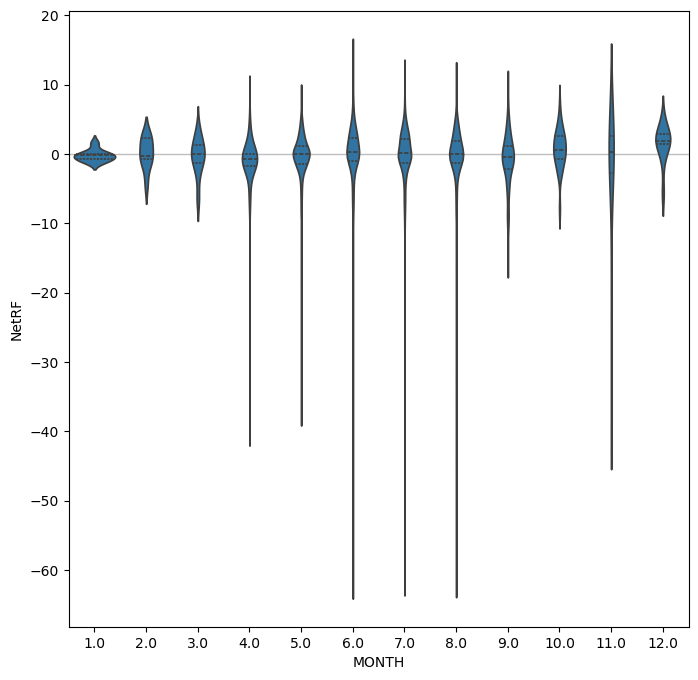

In [34]:
plt.figure(figsize=(8,8))
ax = sns.violinplot(data=df_RF, x='MONTH', y='NetRF', inner='quartile')
ax.axhline(0, color='gray', linewidth=1, alpha=0.5, zorder=0)
plt.show()

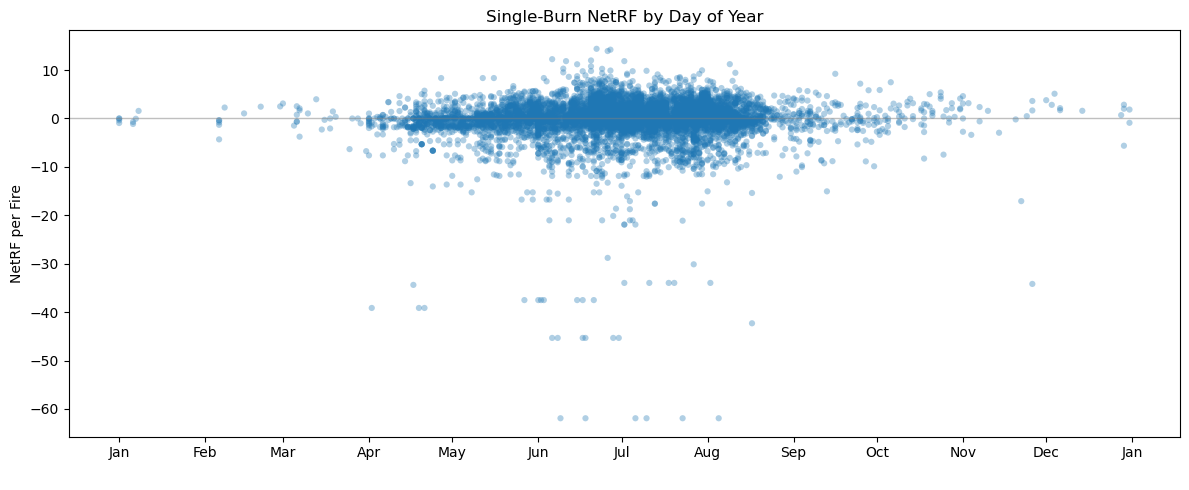

In [43]:
# Plot every fire by calendar day (month + day), combining all years.
import matplotlib.dates as mdates

plot_df = df_filter.copy()

# Clean date parts and NetRF.
plot_df["MONTH"] = pd.to_numeric(plot_df["MONTH"], errors="coerce")
plot_df["DAY"] = pd.to_numeric(plot_df["DAY"], errors="coerce")
plot_df["NetRF"] = pd.to_numeric(plot_df["NetRF"], errors="coerce")

# Use a placeholder year so x-axis is month/day only.
date_parts = pd.DataFrame(
    {
        "year": 2001,
        "month": plot_df["MONTH"],
        "day": plot_df["DAY"],
    }
)
plot_df["month_day"] = pd.to_datetime(date_parts, errors="coerce")

# Keep all individual fires with a constant marker size.
plot_df = plot_df.dropna(subset=["month_day", "NetRF"]).copy()

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(
    plot_df["month_day"],
    plot_df["NetRF"],
    s=20,
    alpha=0.35,
    edgecolors="none",
)
ax.axhline(0, color="gray", linewidth=1, alpha=0.5)

ax.set_title("Single-Burn NetRF by Day of Year")
ax.set_xlabel(" ")
ax.set_ylabel("NetRF per Fire")

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.tight_layout()
plt.show()

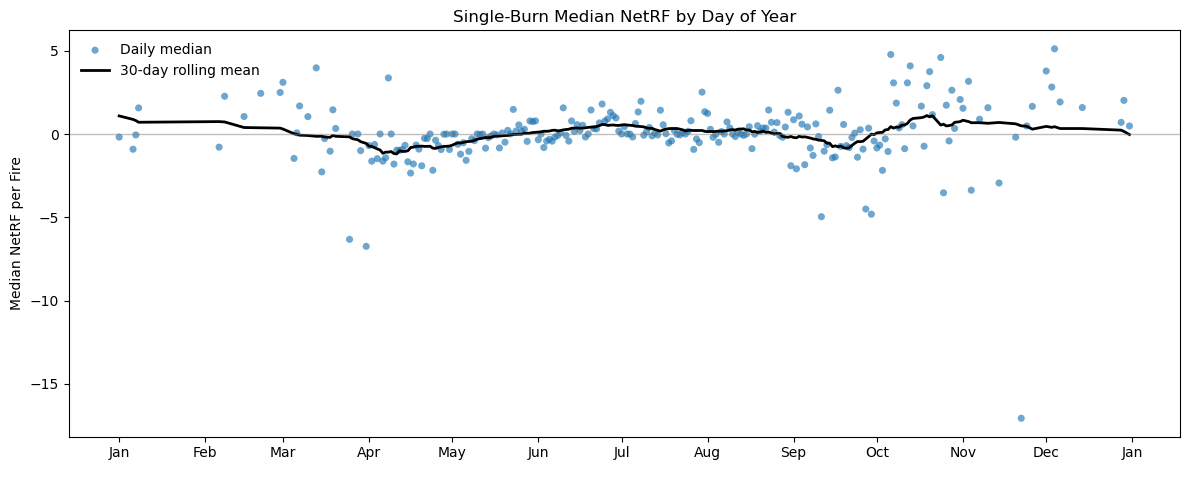

In [45]:
# Median NetRF by calendar day (month + day), with rolling mean overlay.
import matplotlib.dates as mdates

median_df = df_filter.copy()

median_df["MONTH"] = pd.to_numeric(median_df["MONTH"], errors="coerce")
median_df["DAY"] = pd.to_numeric(median_df["DAY"], errors="coerce")
median_df["NetRF"] = pd.to_numeric(median_df["NetRF"], errors="coerce")

date_parts = pd.DataFrame(
    {
        "year": 2001,
        "month": median_df["MONTH"],
        "day": median_df["DAY"],
    }
)
median_df["month_day"] = pd.to_datetime(date_parts, errors="coerce")

median_by_day = (
    median_df.dropna(subset=["month_day", "NetRF"])
    .groupby("month_day", as_index=False)
    .agg(NetRF_median=("NetRF", "median"))
    .sort_values("month_day")
)

# Rolling mean over daily medians (window in days).
window_days = 30
median_by_day["rolling_mean"] = (
    median_by_day["NetRF_median"].rolling(window=window_days, center=True, min_periods=1).mean()
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(
    median_by_day["month_day"],
    median_by_day["NetRF_median"],
    s=26,
    alpha=0.65,
    edgecolors="none",
    label="Daily median",
)
ax.plot(
    median_by_day["month_day"],
    median_by_day["rolling_mean"],
    color="black",
    linewidth=2,
    label=f"{window_days}-day rolling mean",
)
ax.axhline(0, color="gray", linewidth=1, alpha=0.5)

ax.set_title("Single-Burn Median NetRF by Day of Year")
ax.set_xlabel(" ")
ax.set_ylabel("Median NetRF per Fire")

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

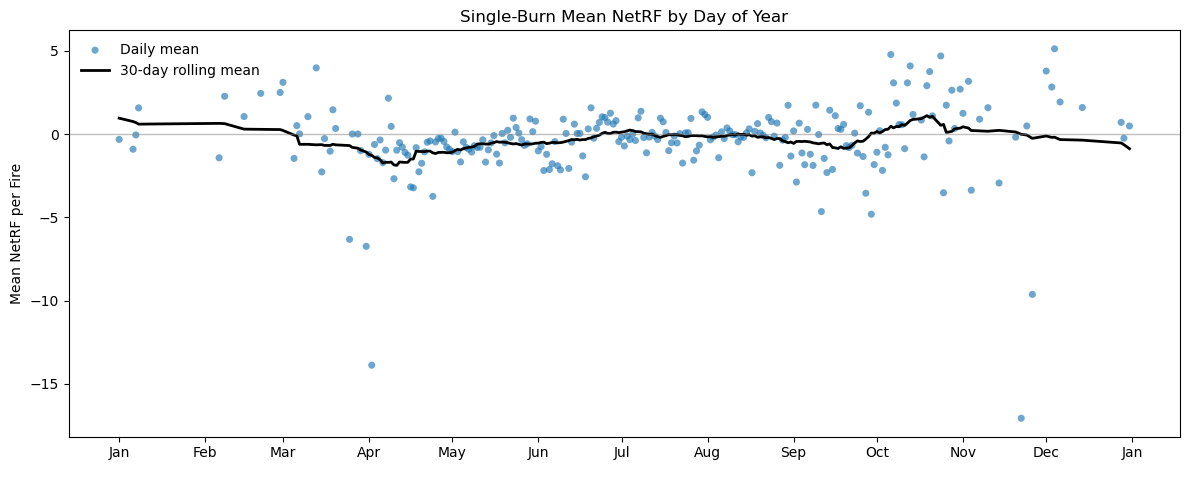

In [46]:
# Mean NetRF by calendar day (month + day), with rolling mean overlay.
mean_by_day = (
    median_df.dropna(subset=["month_day", "NetRF"])
    .groupby("month_day", as_index=False)
    .agg(NetRF_mean=("NetRF", "mean"))
    .sort_values("month_day")
)

mean_by_day["rolling_mean"] = (
    mean_by_day["NetRF_mean"].rolling(window=window_days, center=True, min_periods=1).mean()
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(
    mean_by_day["month_day"],
    mean_by_day["NetRF_mean"],
    s=26,
    alpha=0.65,
    edgecolors="none",
    label="Daily mean",
)
ax.plot(
    mean_by_day["month_day"],
    mean_by_day["rolling_mean"],
    color="black",
    linewidth=2,
    label=f"{window_days}-day rolling mean",
)
ax.axhline(0, color="gray", linewidth=1, alpha=0.5)

ax.set_title("Single-Burn Mean NetRF by Day of Year")
ax.set_xlabel(" ")
ax.set_ylabel("Mean NetRF per Fire")

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [ ]:
#netRF by year, or decade, and by year/decade by ecoregion

In [8]:
df_filter['FIREYEAR'].unique()

array([2019, 2018, 2017, 2016, 2015, 2014, 2013, 2012, 2011, 2010, 2009,
       2008, 2007, 2006, 2005, 2004, 2003, 2002, 2001])

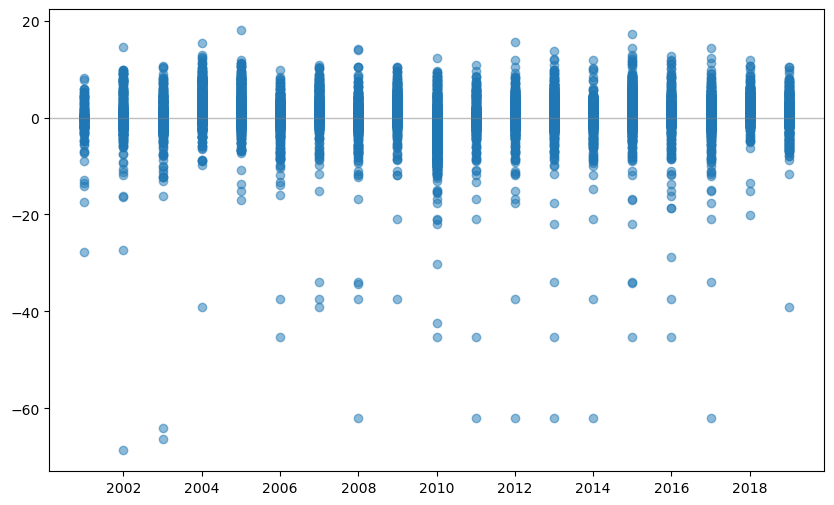

In [22]:

fig, ax = plt.subplots(figsize = (10,6))
ax.plot(df_filter['FIREYEAR'], df_filter['NetRF'], marker='o', linestyle='None', alpha=0.5)
ax.axhline(0, color="gray", linewidth=1, alpha=0.5)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.show()

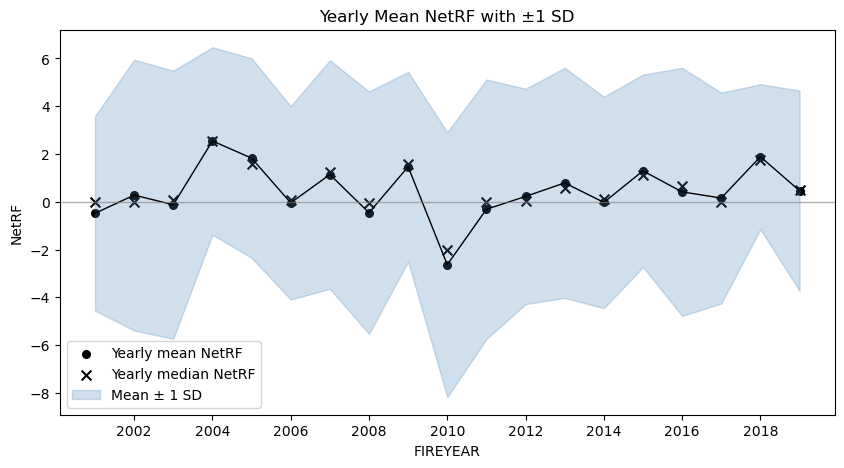

In [25]:
yearly = (
    df_filter.dropna(subset=["FIREYEAR", "NetRF"])
    .groupby("FIREYEAR", as_index=False)["NetRF"]
    .agg(mean="mean", median="median", std="std")
    .sort_values("FIREYEAR")
)

# A year with one observation has NaN std; treat it as 0 for plotting.
yearly["std"] = yearly["std"].fillna(0)

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(yearly["FIREYEAR"], yearly["mean"], color="black", s=30, label="Yearly mean NetRF")
ax.plot(yearly["FIREYEAR"], yearly["mean"], color="black", linewidth=1)
ax.scatter(yearly["FIREYEAR"], yearly["median"], color="black", marker="x", s=50, label="Yearly median NetRF")
ax.fill_between(
    yearly["FIREYEAR"],
    yearly["mean"] - yearly["std"],
    yearly["mean"] + yearly["std"],
    color="steelblue",
    alpha=0.25,
    label="Mean ± 1 SD",
)

ax.axhline(0, color="gray", linewidth=1, alpha=0.6)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_xlabel("FIREYEAR")
ax.set_ylabel("NetRF")
ax.set_title("Yearly Mean NetRF with ±1 SD")
ax.legend()

plt.show()

In [ ]:
#netRF vs fire size

In [ ]:
#could be worth making Max's original line plots by ecoregion and producing one set per decade or something. 
#Find some way to visualize the contributions of each RF input over time